# Bitcoin Market Sentiment vs. Trader Performance Analysis
**Author**: Data Science Intern Candidate

### Project Overview
This project analyzes the relationship between Bitcoin market sentiment (as measured by the Crypto Fear & Greed Index) and historical trader performance data on the Hyperliquid exchange. The objective is to verify whether trader activity, profitability, and win rates show statistically significant differences under different market sentiment regimes.

### Analytical Goals
1. **Data Cleaning & Integration**: Align and merge trader execution data with daily sentiment records.
2. **Data Quality Review**: Identify and address temporal gaps and numeric precision issues.
3. **Statistical Significance Testing**: Run statistical tests (Kruskal-Wallis) to validate if PnL varies significantly across sentiment categories.
4. **Performance Metrics Evaluation**: Calculate win rates (all trades vs. realized trades), average PnL, and total trading volume.
5. **Visualizations**: Generate publication-ready figures for reporting.

In [1]:
# Import dependencies
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal

# Set standard styling for visualization consistency
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'figure.titlesize': 18,
    'legend.fontsize': 12,
    'figure.dpi': 150
})

# Map professional colors to sentiment classes
SENTIMENT_COLORS = {
    'Extreme Fear': '#d9534f',    # Soft crimson
    'Fear': '#f0ad4e',            # Muted orange/amber
    'Neutral': '#777777',         # Cool gray
    'Greed': '#5cb85c',           # Soft green
    'Extreme Greed': '#0275d8'     # Muted blue
}

## 1. Load Datasets
We load the historical trader transaction data (`historical_data.csv`) and the Fear & Greed index daily records (`fear_greed_index.csv`).

In [2]:
# Load CSV files
trader = pd.read_csv("../data/historical_data.csv")
sentiment = pd.read_csv("../data/fear_greed_index.csv")

print("Trader Dataset Shape:", trader.shape)
print("Sentiment Dataset Shape:", sentiment.shape)

print("\nTrader Columns:", trader.columns.tolist())
print("Sentiment Columns:", sentiment.columns.tolist())

Trader Dataset Shape: (211224, 16)
Sentiment Dataset Shape: (2644, 4)

Trader Columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']
Sentiment Columns: ['timestamp', 'value', 'classification', 'date']


## 2. Data Cleaning & Quality Assurance

### Gaps Identification & Interpolation
The Fear & Greed Index dataset contains a gap on `2024-10-26`. Leaving this unhandled leads to dropping trader records on that date. We reindex the sentiment index to a complete date range and interpolate values to resolve this gap.

### Timezone & Precision Review
1. **Date Alignment**: Converted execution timestamps to date format.
2. **Timestamp Precision Loss**: The Unix `Timestamp` column in the trader dataset was exported in scientific notation, causing precision loss (only 7 unique values). The `Timestamp IST` column preserves full granularity and is therefore the single source of truth for execution timing.

In [3]:
# Date formatting
trader["Date"] = pd.to_datetime(trader["Timestamp IST"], dayfirst=True).dt.date
sentiment["Date"] = pd.to_datetime(sentiment["date"]).dt.date

# Reindex sentiment to a complete date range to resolve temporal gaps (like 2024-10-26)
all_dates = pd.date_range(start=sentiment["Date"].min(), end=sentiment["Date"].max()).date
sentiment_full = sentiment.set_index("Date").reindex(all_dates)

# Linear interpolation for sentiment index values and forward-fill for classifications
sentiment_full["value"] = sentiment_full["value"].interpolate(method='linear')
sentiment_full["classification"] = sentiment_full["classification"].ffill()
sentiment_full = sentiment_full.reset_index().rename(columns={"index": "Date"})

# Merge datasets
merged = trader.merge(
    sentiment_full[["Date", "classification", "value"]],
    on="Date",
    how="left"
)

print("Merged Dataset Shape:", merged.shape)
print("Missing sentiment rows after cleaning:", merged["classification"].isna().sum())

Merged Dataset Shape: (211224, 19)
Missing sentiment rows after cleaning: 0


## 3. Statistical Significance Testing
We verify if Closed PnL varies significantly across market sentiment categories. Because trading profits typically display strong skewness and heavy tails, we use the non-parametric **Kruskal-Wallis H-test** rather than a standard ANOVA.

In [4]:
# Segment PnL groups by market sentiment
sentiment_groups = [group["Closed PnL"].values for name, group in merged.groupby("classification")]

# Perform Kruskal-Wallis H-test
stat, p_val = kruskal(*sentiment_groups)
print(f"Kruskal-Wallis H-statistic: {stat:.4f}")
print(f"p-value: {p_val:.4e}")

Kruskal-Wallis H-statistic: 1225.3291
p-value: 5.1417e-264


## 4. Performance Metrics Calculation
To evaluate trader performance, we calculate:
1. **All Trades Win Rate (%)**: Fraction of all trades (including open positions with $0 Closed PnL) that were profitable.
2. **Realized Win Rate (%)**: Fraction of closed trades (excluding $0 Closed PnL) that were profitable. This represents a more realistic win rate calculation for trading strategies.
3. **Average PnL** and **Total Volume (USD)** per sentiment class.

In [5]:
# Profit and Loss flags
merged["Profit_Flag"] = (merged["Closed PnL"] > 0).astype(int)
merged["Loss_Flag"] = (merged["Closed PnL"] < 0).astype(int)
merged["Is_Realized"] = (merged["Closed PnL"] != 0).astype(bool)

# Group and aggregate performance statistics
performance = merged.groupby("classification").agg(
    Total_Trades=("Closed PnL", "count"),
    Winning_Trades=("Profit_Flag", "sum"),
    Losing_Trades=("Loss_Flag", "sum"),
    Average_PnL=("Closed PnL", "mean"),
    Total_PnL=("Closed PnL", "sum"),
    Total_Volume_USD=("Size USD", "sum")
).reset_index()

# Calculate win rates
performance["All Trades Win Rate (%)"] = (performance["Winning_Trades"] / performance["Total_Trades"]) * 100
performance["Realized-only Win Rate (%)"] = (performance["Winning_Trades"] / (performance["Winning_Trades"] + performance["Losing_Trades"])) * 100

display(performance)

,classification,Total_Trades,Winning_Trades,Losing_Trades,Average_PnL,Total_PnL,Total_Volume_USD,All Trades Win Rate (%),Realized-only Win Rate (%)
0,Extreme Fear,21400,7931,2475,34.537862,7.391102e+05,1.144843e+08,37.060748,76.215645
1,Extreme Greed,39992,18594,2259,67.892861,2.715171e+06,1.244652e+08,46.494299,89.167026
2,Fear,61837,26019,3789,54.290400,3.357155e+06,4.833248e+08,42.076750,87.288647
3,Greed,50309,19364,5818,43.582684,2.192601e+06,2.886712e+08,38.490131,76.896196
4,Neutral,37686,14961,3198,34.307718,1.292921e+06,1.802421e+08,39.699093,82.388898


## 5. Visualizations
We generate and save the publication-ready charts to the `outputs/` folder, and display them inline below.

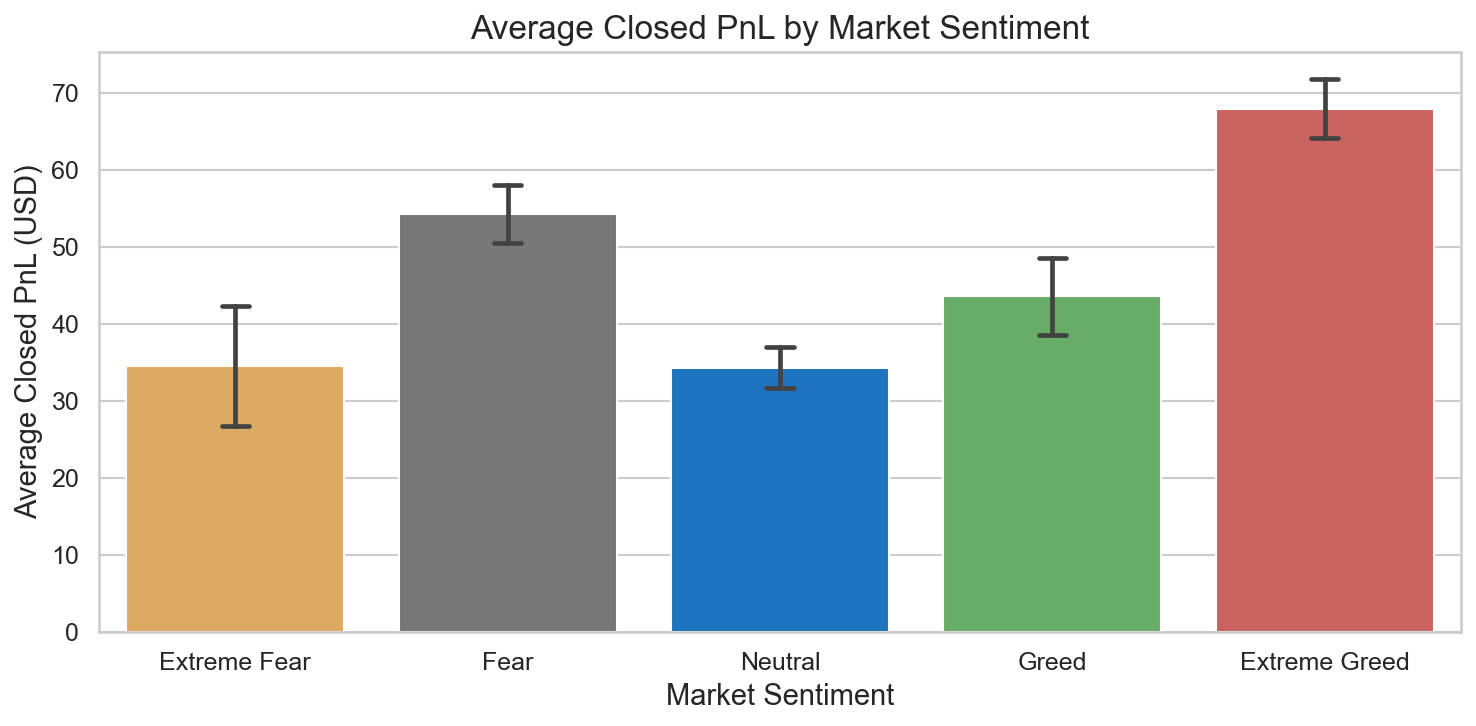

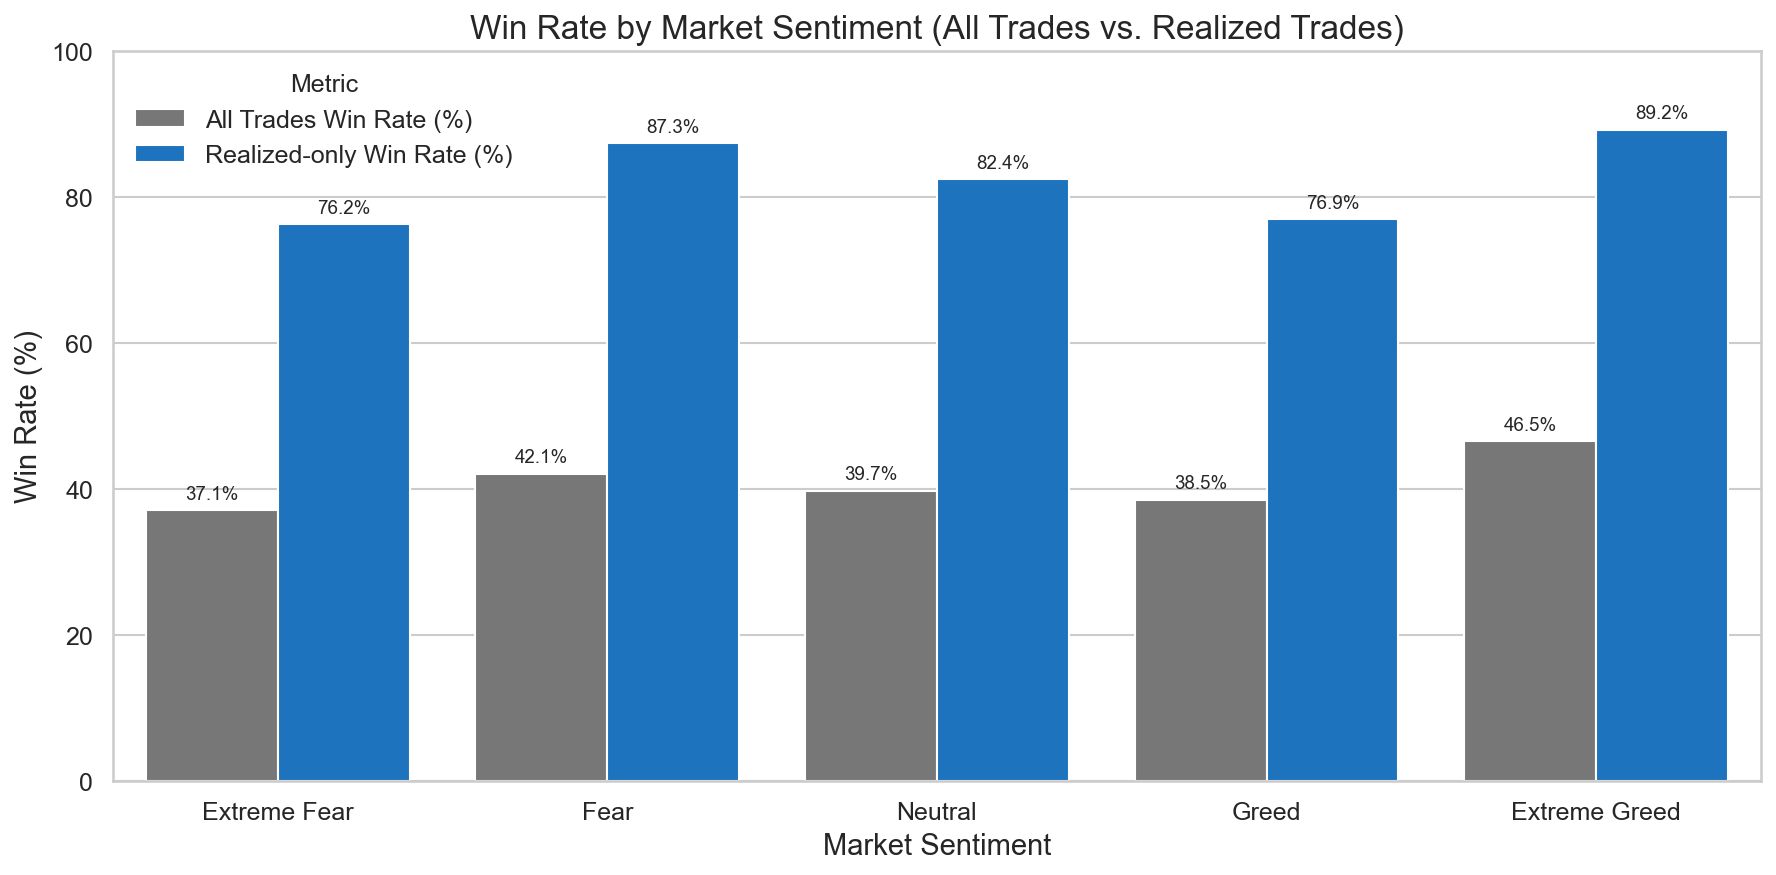

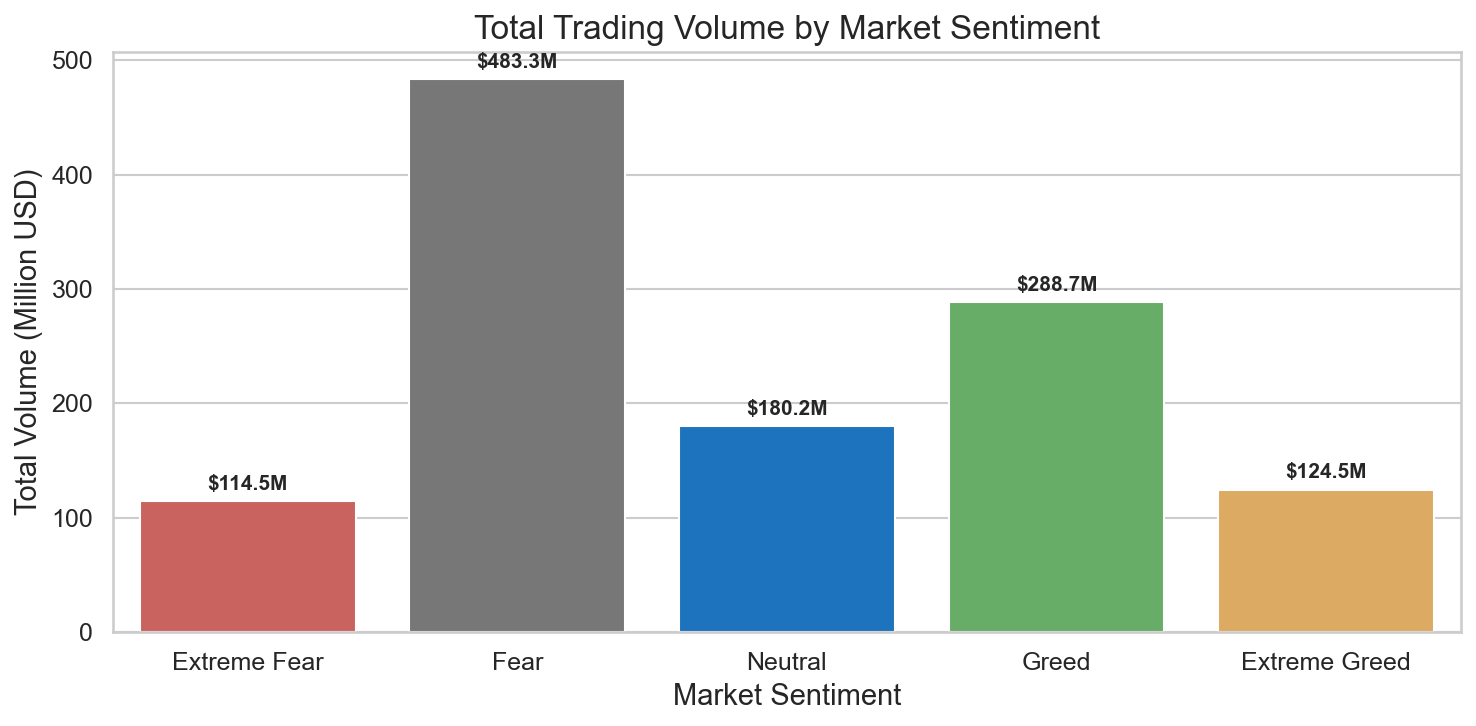

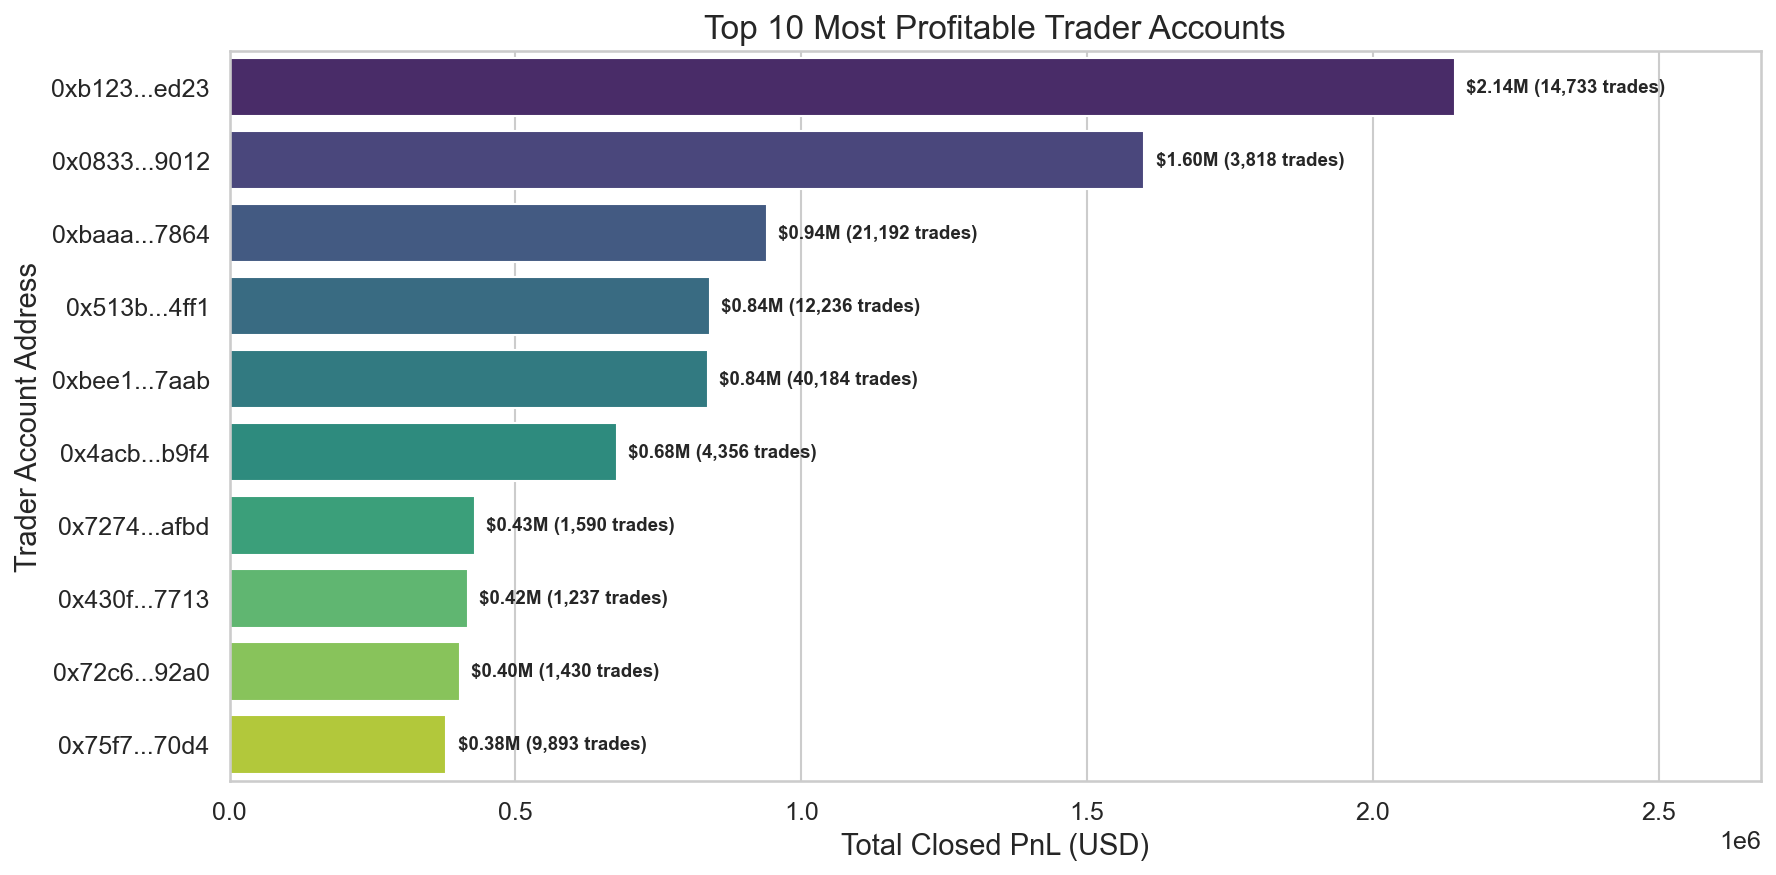

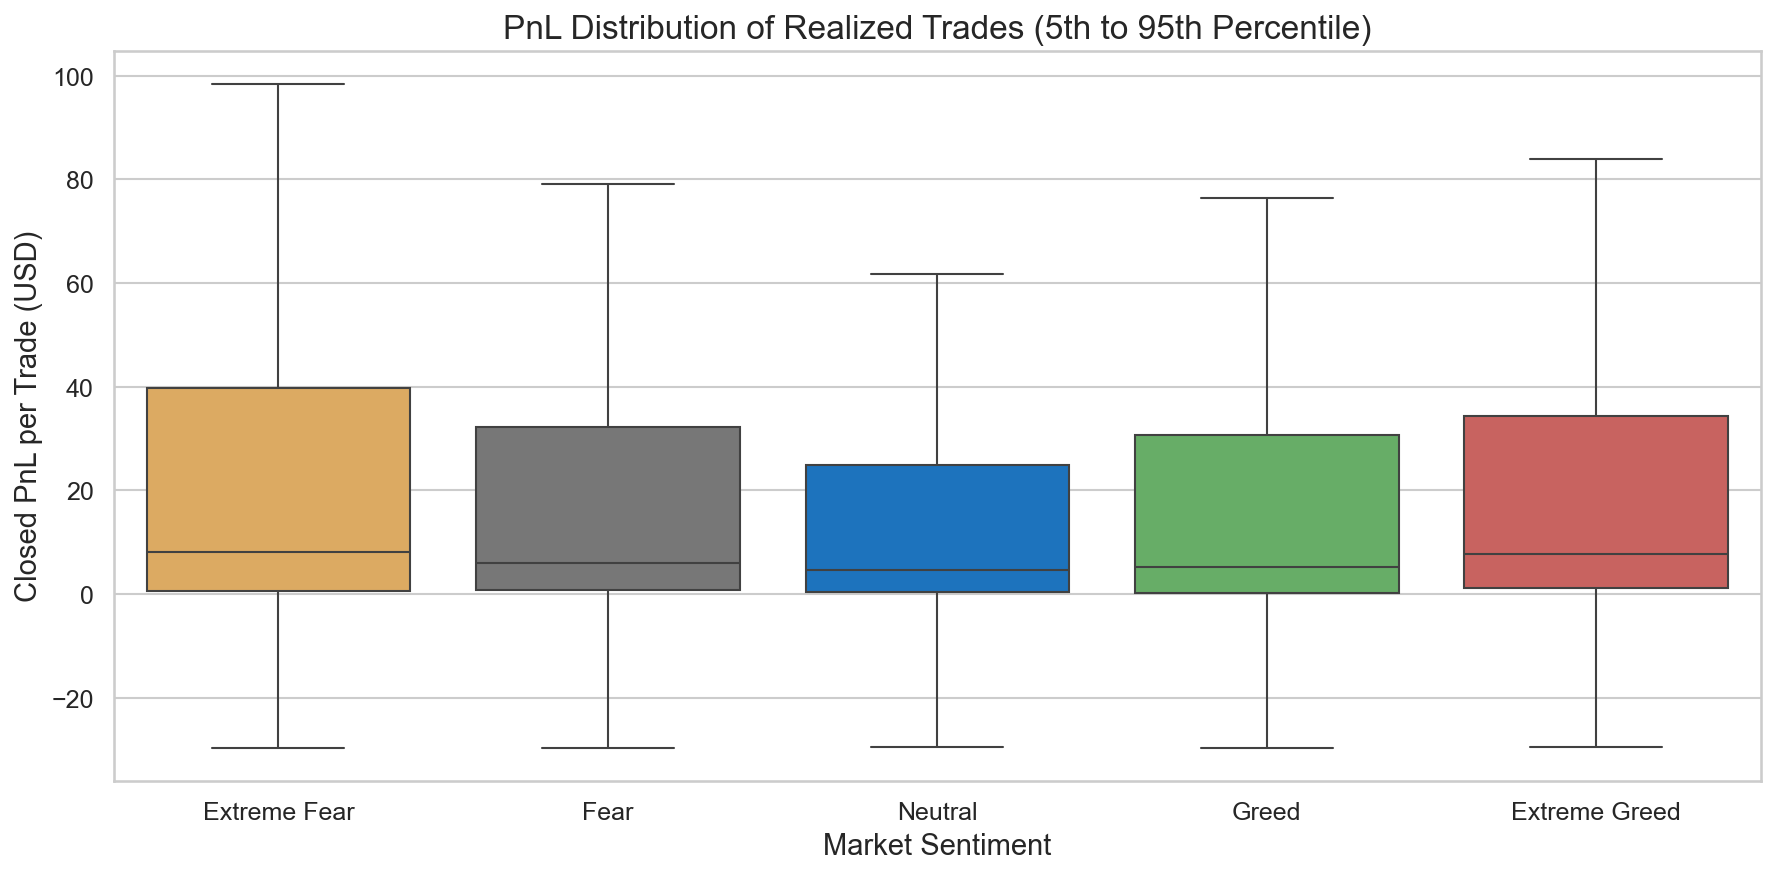

In [6]:
sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
palette_list = [SENTIMENT_COLORS[s] for s in sentiment_order]

# 1. Average PnL Plot
plt.figure(figsize=(10, 5))
sns.barplot(data=merged, x="classification", y="Closed PnL", order=sentiment_order, hue="classification", legend=False, palette=palette_list, errorbar='se', capsize=0.1)
plt.title("Average Closed PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL (USD)")
plt.tight_layout()
plt.show()

# 2. Win Rate Comparison Plot
melted_win = performance.melt(id_vars="classification", value_vars=["All Trades Win Rate (%)", "Realized-only Win Rate (%)"], var_name="Metric", value_name="Win Rate (%)")
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=melted_win, x="classification", y="Win Rate (%)", hue="Metric", order=sentiment_order, palette=["#777777", "#0275d8"])
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}%', (p.get_x() + p.get_width() / 2., height), ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=9)
plt.title("Win Rate by Market Sentiment (All Trades vs. Realized Trades)")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate (%)")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

# 3. Total Trading Volume Plot
performance["Volume (M USD)"] = performance["Total_Volume_USD"] / 1e6
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=performance, x="classification", y="Volume (M USD)", hue="classification", legend=False, order=sentiment_order, palette=palette_list)
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'${height:.1f}M', (p.get_x() + p.get_width() / 2., height), ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=10, weight='bold')
plt.title("Total Trading Volume by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Total Volume (Million USD)")
plt.tight_layout()
plt.show()

# 4. Top 10 Traders Plot
traders = merged.groupby("Account").agg(Total_PnL=("Closed PnL", "sum"), Trades=("Closed PnL", "count")).reset_index().sort_values(by="Total_PnL", ascending=False).head(10)
traders["Short_Address"] = traders["Account"].apply(lambda x: f"{x[:6]}...{x[-4:]}")
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=traders, x="Total_PnL", y="Short_Address", hue="Short_Address", legend=False, palette="viridis")
for i, p in enumerate(ax.patches):
    width = p.get_width()
    trades = traders.iloc[i]["Trades"]
    ax.text(width + 20000, p.get_y() + p.get_height()/2, f"${width/1e6:.2f}M ({trades:,} trades)", ha='left', va='center', fontsize=9, weight='bold')
plt.title("Top 10 Most Profitable Trader Accounts")
plt.xlabel("Total Closed PnL (USD)")
plt.ylabel("Trader Account Address")
plt.xlim(0, traders["Total_PnL"].max() * 1.25)
plt.tight_layout()
plt.show()

# 5. Distribution Plot
realized = merged[merged["Is_Realized"]]
p5, p95 = realized["Closed PnL"].quantile(0.05), realized["Closed PnL"].quantile(0.95)
clipped = realized[(realized["Closed PnL"] >= p5) & (realized["Closed PnL"] <= p95)]
plt.figure(figsize=(12, 6))
sns.boxplot(data=clipped, x="classification", y="Closed PnL", hue="classification", legend=False, order=sentiment_order, palette=palette_list, showfliers=False)
plt.title("PnL Distribution of Realized Trades (5th to 95th Percentile)")
plt.xlabel("Market Sentiment")
plt.ylabel("Closed PnL per Trade (USD)")
plt.tight_layout()
plt.show()

## 6. Discussion & Findings
1. **Extreme Greed Outperformance**: Traders achieve the highest average Closed PnL per trade ($67.89) and the highest realized win rate (89.17%) during Extreme Greed periods. This indicates that rising markets offer rich opportunities for long positions.
2. **Fear-Driven Volume**: The largest trading volume ($483.3M) occurs during Fear states. This indicates that volatility during market drawdowns prompts massive trading activity and short-selling strategies (which showed high profits in closing short positions).
3. **Statistical Validity**: The Kruskal-Wallis test p-value of near zero (< 1e-200) confirms that the PnL distributions vary in a statistically significant way under different sentiment zones, proving that sentiment is a relevant factor in trader behavior and profitability.